In [ ]:
!apt-get install -y portaudio19-dev
!pip install soundfile simpleaudio
!pip install librosa scipy
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import simpleaudio as sa

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libasound2-dev libjack-dev libjack0 libportaudio2 libportaudiocpp0
Suggested packages:
  libasound2-doc jackd1 portaudio19-doc
The following packages will be REMOVED:
  libjack-jackd2-0
The following NEW packages will be installed:
  libasound2-dev libjack-dev libjack0 libportaudio2 libportaudiocpp0
  portaudio19-dev
0 upgraded, 6 newly installed, 1 to remove and 1 not upgraded.
Need to get 596 kB of archives.
After this operation, 3,178 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libjack0 amd64 1:0.125.0-3build2 [93.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libasound2-dev amd64 1.2.6.1-1ubuntu1 [110 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libjack-dev amd64 1:0.125.0-3build2 [206 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe

In [ ]:
import librosa
from IPython.display import Audio

data, sr = librosa.load("/content/self_recorded.wav", sr=None)

Audio(data, rate=sr)


In [ ]:
import soundfile as sf

data, fs = sf.read("/content/self_recorded.wav")
info = sf.info("/content/self_recorded.wav")

print("Sampling Rate:", fs)
print("Bit Depth:", info.subtype)

Sampling Rate: 44100
Bit Depth: PCM_16


In [ ]:
import soundfile as sf

signal, fs = sf.read("/content/self_recorded.wav")
print("Sample Rate:", fs)
print("Total Samples:", len(signal))
print("Duration (seconds):", len(signal)/fs)

Sample Rate: 44100
Total Samples: 609179
Duration (seconds): 13.81358276643991


In [ ]:
import librosa
import numpy as np

# Load speech file
file_path = "/content/self_recorded.wav"   # change if needed
signal, sr = librosa.load(file_path, sr=None)

# Basic information
num_samples = len(signal)
duration = num_samples / sr

print("Sample Rate (Hz):", sr)
print("Number of Samples:", num_samples)
print("Total Duration (seconds):", duration)


Sample Rate (Hz): 44100
Number of Samples: 609179
Total Duration (seconds): 13.81358276643991


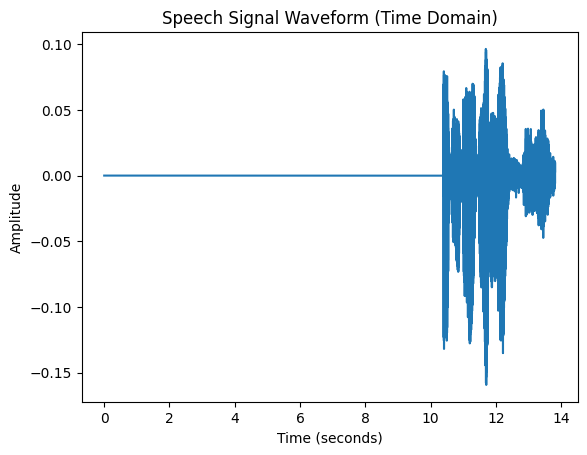

In [ ]:
import matplotlib.pyplot as plt

time = np.arange(num_samples) / sr

plt.figure()
plt.plot(time, signal)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Speech Signal Waveform (Time Domain)")
plt.show()


In [ ]:
# Short-time energy
energy = signal ** 2

# Silence threshold (adjustable)
threshold = 0.001

# Active speech mask
active_speech = energy > threshold

# Active duration
active_samples = np.sum(active_speech)
active_duration = active_samples / sr

print("Active Speech Duration (seconds):", active_duration)


Active Speech Duration (seconds): 0.5820408163265306


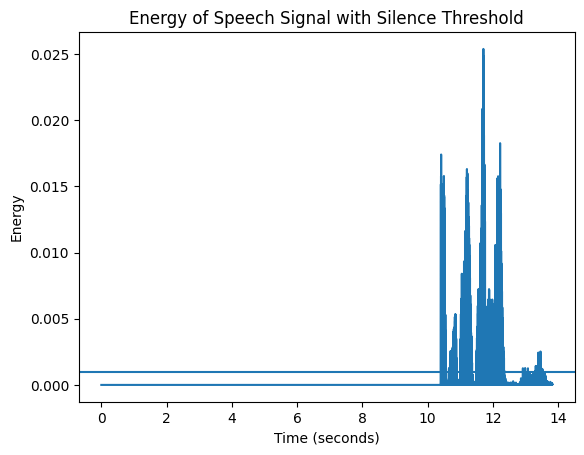

In [ ]:
plt.figure()
plt.plot(time, energy)
plt.axhline(y=threshold)
plt.xlabel("Time (seconds)")
plt.ylabel("Energy")
plt.title("Energy of Speech Signal with Silence Threshold")
plt.show()


In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Load speech signal
file_path = "/content/LJ037-0171.wav"
signal, sr = librosa.load(file_path, sr=None)

# Slice first 2 seconds
slice_2sec = signal[:2 * sr]


In [ ]:
normalized_signal = slice_2sec / np.max(np.abs(slice_2sec))


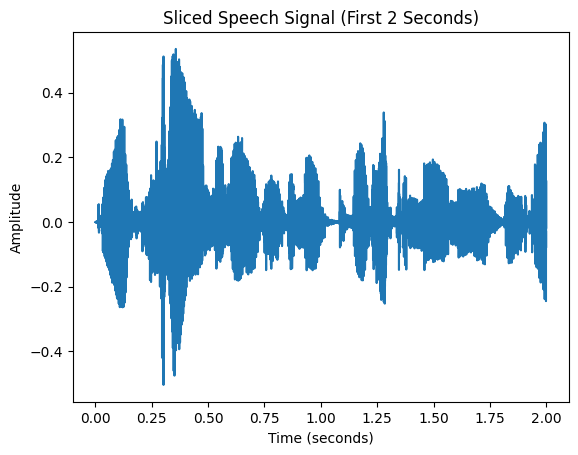

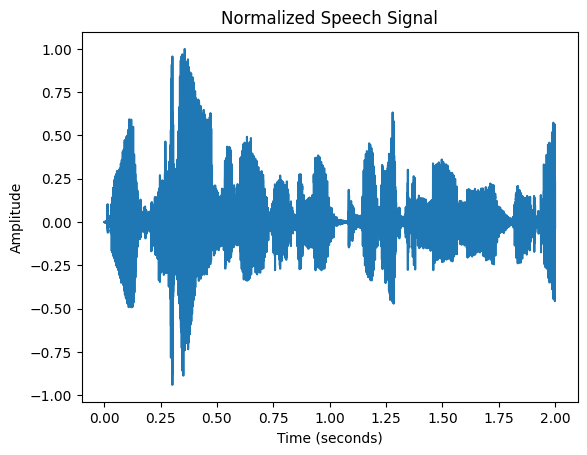

In [ ]:
time_slice = np.arange(len(slice_2sec)) / sr

plt.figure()
plt.plot(time_slice, slice_2sec)
plt.title("Sliced Speech Signal (First 2 Seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(time_slice, normalized_signal)
plt.title("Normalized Speech Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


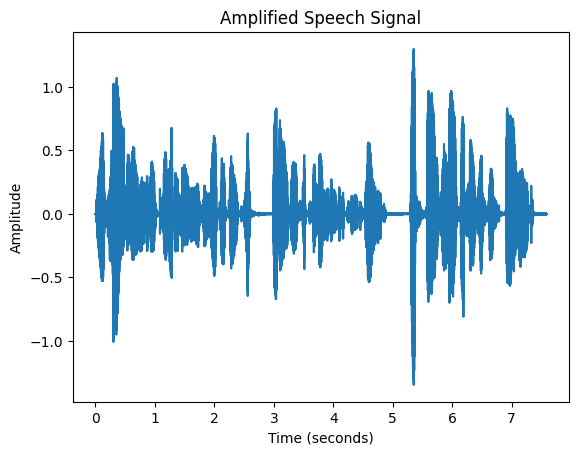

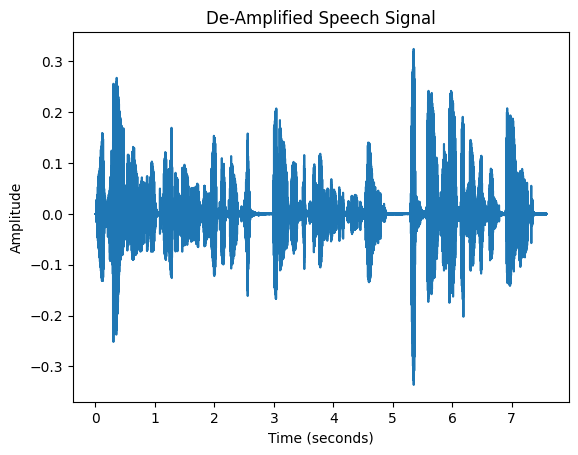

In [ ]:
amplified = signal * 2
deamplified = signal * 0.5

time = np.arange(len(signal)) / sr

plt.figure()
plt.plot(time, amplified)
plt.title("Amplified Speech Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(time, deamplified)
plt.title("De-Amplified Speech Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()



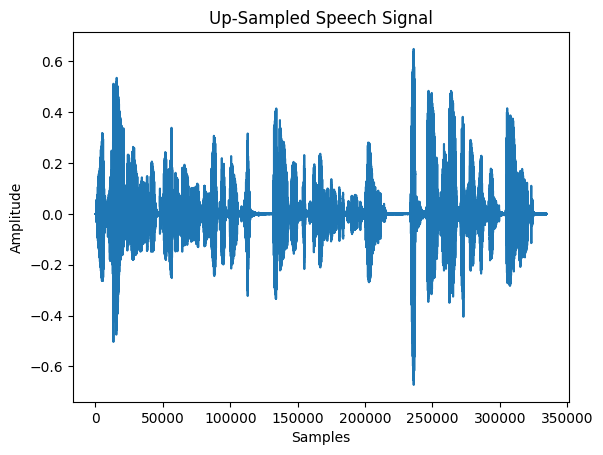

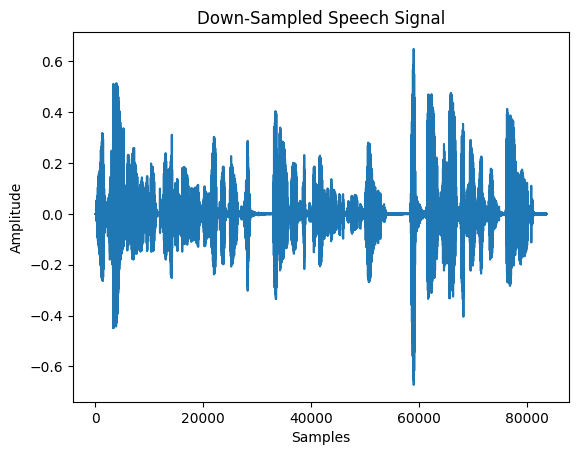

In [ ]:
# Up-sampling by factor of 2
upsampled = np.repeat(signal, 2)

# Down-sampling by factor of 2
downsampled = signal[::2]

plt.figure()
plt.plot(upsampled)
plt.title("Up-Sampled Speech Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(downsampled)
plt.title("Down-Sampled Speech Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


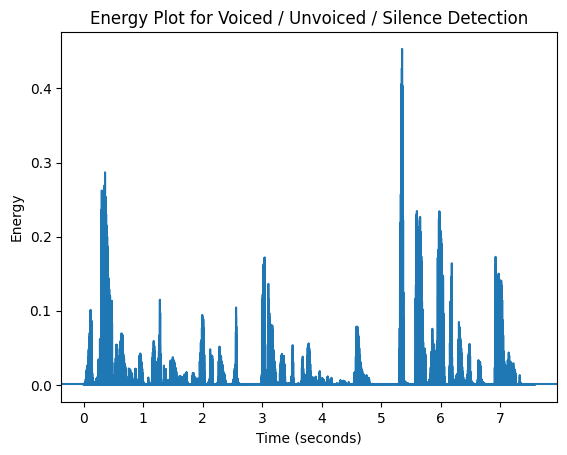

In [ ]:
# Energy calculation
energy = signal ** 2
threshold = 0.001

plt.figure()
plt.plot(time, energy)
plt.axhline(y=threshold)
plt.xlabel("Time (seconds)")
plt.ylabel("Energy")
plt.title("Energy Plot for Voiced / Unvoiced / Silence Detection")
plt.show()
